### 1. Generate a synthetic binary classification dataset using a Gaussian Mixture Model (two components, one per class). Train a Gaussian Naive Bayes classifier on the data.

#### a. Compare the learned class-conditional distributions with the true generating distributions.
#### b. Comment on where and why they differ.

* We generate data from a Gaussian Mixture Model (GMM)
* Gaussian Naive Bayes (GNB) assumes: a) Features are conditionally independent  b) Each feature follows a Gaussian distribution

TRUE MEANS:
Class 0: [0, 0]
Class 1: [3, 3]

LEARNED MEANS (Naive Bayes):
Class 0: [0.03318614 0.05698215]
Class 1: [2.98918258 2.99793242]

TRUE VARIANCES:
Class 0: [1 1]
Class 1: [1 1]

LEARNED VARIANCES (Naive Bayes):
Class 0: [0.92375632 1.02911221]
Class 1: [1.01541783 1.00500669]


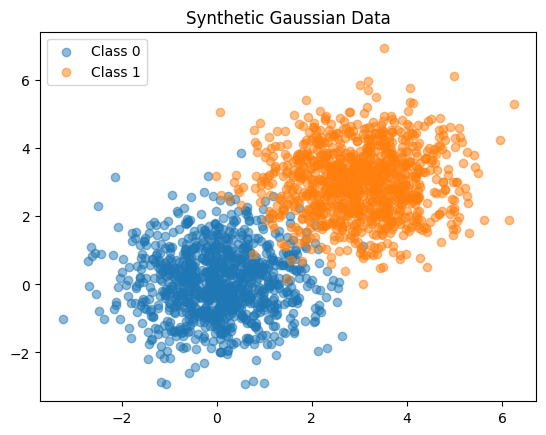

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB

np.random.seed(42)

n_samples = 1000

mu_class0 = [0, 0]
mu_class1 = [3, 3]

cov_class0 = [[1, 0], [0, 1]]
cov_class1 = [[1, 0], [0, 1]]

X0 = np.random.multivariate_normal(mu_class0, cov_class0, n_samples)
X1 = np.random.multivariate_normal(mu_class1, cov_class1, n_samples)

X = np.vstack((X0, X1))
y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))

gnb = GaussianNB()
gnb.fit(X, y)

learned_means = gnb.theta_
learned_variances = gnb.var_


print("TRUE MEANS:")
print("Class 0:", mu_class0)
print("Class 1:", mu_class1)

print("\nLEARNED MEANS (Naive Bayes):")
print("Class 0:", learned_means[0])
print("Class 1:", learned_means[1])

print("\nTRUE VARIANCES:")
print("Class 0:", np.diag(cov_class0))
print("Class 1:", np.diag(cov_class1))

print("\nLEARNED VARIANCES (Naive Bayes):")
print("Class 0:", learned_variances[0])
print("Class 1:", learned_variances[1])


plt.scatter(X0[:, 0], X0[:, 1], alpha=0.5, label="Class 0")
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.5, label="Class 1")
plt.legend()
plt.title("Synthetic Gaussian Data")
plt.show()


### The learned distributions differ from the true generating distributions because Gaussian Naive Bayes enforces a diagonal covariance structure. When features are correlated in the data-generating process, this assumption is violated, leading to approximation errors in parameter estimation.